In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [5]:
import os

path = r'C:\Users\steff\OneDrive\Desktop\Final Project\Supply Chain Analytics - Project 1'

suppliers =       pd.read_csv(os.path.join(path, 'suppliers.csv'))
purchase_orders = pd.read_csv(os.path.join(path, 'purchase_orders.csv'), 
                               parse_dates=['order_date', 'promised_delivery_date', 'actual_delivery_date'])
inventory =       pd.read_csv(os.path.join(path, 'inventory.csv'))
logistics =       pd.read_csv(os.path.join(path, 'logistics.csv'))
production =      pd.read_csv(os.path.join(path, 'production.csv'), parse_dates=['date'])
sales_forecast =  pd.read_csv(os.path.join(path, 'sales_forecast.csv'), parse_dates=['date'])
calendar =        pd.read_csv(os.path.join(path, 'calendar.csv'), parse_dates=['date'])

print("All files loaded successfully")

All files loaded successfully


In [8]:

purchase_orders['delay_days'] = (
    purchase_orders['actual_delivery_date'] - purchase_orders['promised_delivery_date']
).dt.days

# Merge purchase orders with logistics
po_logistics = purchase_orders.merge(logistics, on='purchase_order_id', how='inner')

# Merge purchase orders with suppliers
po_suppliers = purchase_orders.merge(suppliers, on='supplier_id', how='inner')

print(f"PO + Logistics merged: {len(po_logistics)} rows")
print(f"PO + Suppliers merged: {len(po_suppliers)} rows")
print(f"\nDelay stats:\n{purchase_orders['delay_days'].describe()}")

PO + Logistics merged: 700 rows
PO + Suppliers merged: 800 rows

Delay stats:
count    800.000000
mean       3.366250
std        3.495337
min       -2.000000
25%        0.000000
50%        3.000000
75%        6.000000
max        9.000000
Name: delay_days, dtype: float64


=== Hypothesis Test: Supplier Delays vs Production Downtime ===
H0: No difference in downtime between delayed and on-time deliveries
H1: Delayed deliveries cause higher production downtime

Delayed orders  - Mean downtime: 1.75 hrs, N=307
On-time orders  - Mean downtime: 1.53 hrs, N=132

T-statistic: 1.2760
P-value: 0.2026

Conclusion: Fail to reject H0 — no significant difference found


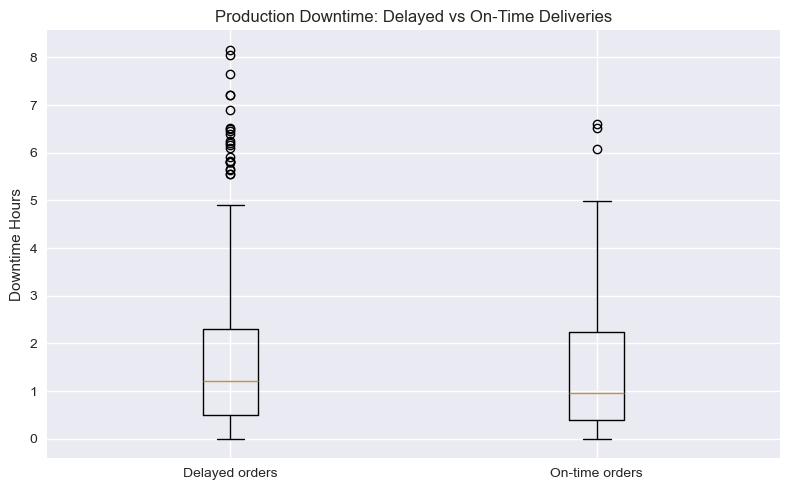

In [9]:
# Merge to link supplier delays with production downtime
# Use order date to match with production date
po_prod = purchase_orders.merge(
    production[['date', 'downtime_hours', 'downtime_reason']], 
    left_on='order_date', 
    right_on='date', 
    how='inner'
)

# Split into delayed vs on-time groups
delayed = po_prod[po_prod['delay_days'] > 0]['downtime_hours']
on_time = po_prod[po_prod['delay_days'] <= 0]['downtime_hours']

# T-test
t_stat, p_value = stats.ttest_ind(delayed, on_time)

print("=== Hypothesis Test: Supplier Delays vs Production Downtime ===")
print(f"H0: No difference in downtime between delayed and on-time deliveries")
print(f"H1: Delayed deliveries cause higher production downtime")
print(f"\nDelayed orders  - Mean downtime: {delayed.mean():.2f} hrs, N={len(delayed)}")
print(f"On-time orders  - Mean downtime: {on_time.mean():.2f} hrs, N={len(on_time)}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nConclusion: {'Reject H0 — delays significantly affect downtime' if p_value < 0.05 else 'Fail to reject H0 — no significant difference found'}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([delayed.dropna(), on_time.dropna()], labels=['Delayed orders', 'On-time orders'])
ax.set_ylabel('Downtime Hours')
ax.set_title('Production Downtime: Delayed vs On-Time Deliveries')
plt.tight_layout()
plt.savefig('hypothesis_test.png', dpi=150)
plt.show()

=== Regression: Predicting Logistics Cost ===

R² Score: 0.0048

Coefficients:
  Transport Mode: -72.6625
  Transit Delay Days: -5.7917
  Quantity: 0.2773

Intercept: 2562.6188

Interpretation: Each extra day of transit delay adds $-5.79 to shipment cost


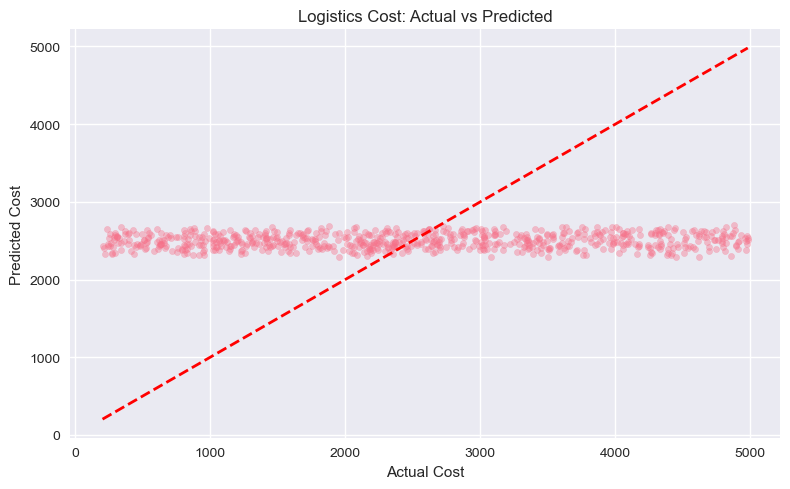

In [10]:
# Encode transport mode
le = LabelEncoder()
po_logistics['transport_encoded'] = le.fit_transform(po_logistics['transport_mode'])

# Features and target
X = po_logistics[['transport_encoded', 'transit_delay_days', 'quantity']].fillna(0)
y = po_logistics['shipment_cost']

# Fit regression
reg = LinearRegression()
reg.fit(X, y)

print("=== Regression: Predicting Logistics Cost ===")
print(f"\nR² Score: {reg.score(X, y):.4f}")
print(f"\nCoefficients:")
for feature, coef in zip(['Transport Mode', 'Transit Delay Days', 'Quantity'], reg.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercept: {reg.intercept_:.4f}")
print(f"\nInterpretation: Each extra day of transit delay adds ${reg.coef_[1]:.2f} to shipment cost")

# Plot actual vs predicted
y_pred = reg.predict(X)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y, y_pred, alpha=0.4, s=20)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax.set_xlabel('Actual Cost')
ax.set_ylabel('Predicted Cost')
ax.set_title('Logistics Cost: Actual vs Predicted')
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=150)
plt.show()

=== Correlation: Lead Time vs Stock-Out Frequency ===

Pearson Correlation: 0.3287
P-value: 0.0762

Interpretation: Weak or no significant correlation detected


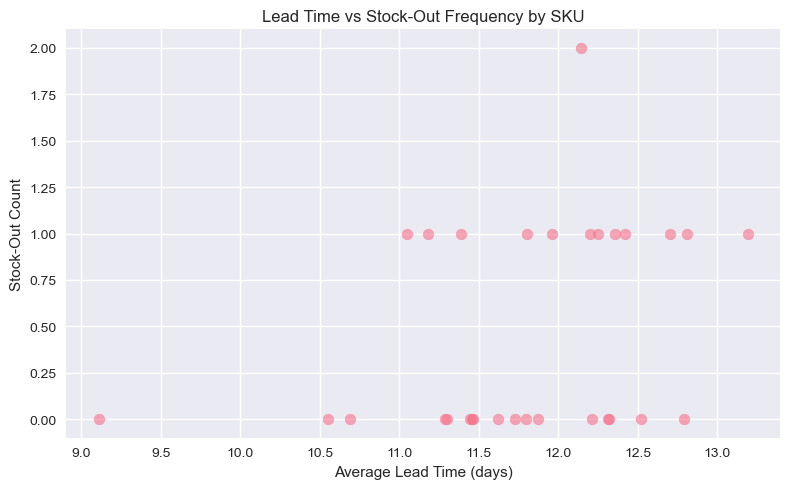

In [11]:
# Calculate lead time per order
purchase_orders['lead_time'] = (
    purchase_orders['actual_delivery_date'] - purchase_orders['order_date']
).dt.days

# Aggregate by SKU — avg lead time
sku_lead = purchase_orders.groupby('sku')['lead_time'].mean().reset_index()
sku_lead.columns = ['sku', 'avg_lead_time']

# Stock-out indicator from inventory
inventory['is_stockout'] = (inventory['current_stock'] < inventory['reorder_level']).astype(int)
sku_stockout = inventory.groupby('sku')['is_stockout'].sum().reset_index()
sku_stockout.columns = ['sku', 'stockout_count']

# Merge and correlate
sku_analysis = sku_lead.merge(sku_stockout, on='sku', how='inner')
corr, p_val = stats.pearsonr(sku_analysis['avg_lead_time'], sku_analysis['stockout_count'])

print("=== Correlation: Lead Time vs Stock-Out Frequency ===")
print(f"\nPearson Correlation: {corr:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"\nInterpretation: {'Significant positive correlation — longer lead times linked to more stock-outs' if corr > 0 and p_val < 0.05 else 'Weak or no significant correlation detected'}")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sku_analysis['avg_lead_time'], sku_analysis['stockout_count'], alpha=0.6, s=60)
ax.set_xlabel('Average Lead Time (days)')
ax.set_ylabel('Stock-Out Count')
ax.set_title('Lead Time vs Stock-Out Frequency by SKU')
plt.tight_layout()
plt.savefig('correlation_plot.png', dpi=150)
plt.show()

=== Outlier Detection: Logistics Cost Spikes ===

IQR Range: $-2092.29 — $7033.02
Outliers detected: 0 shipments (0.0% of total)

Top 5 most expensive outlier shipments:
Empty DataFrame
Columns: [shipment_id, transport_mode, shipment_cost, transit_delay_days]
Index: []

=== Outlier Detection: Production Downtime ===
Extreme downtime incidents: 63
Threshold: >5.83 hours
     production_id    downtime_reason  downtime_hours
987       PR000988        Maintenance           17.60
1144      PR001145  Material Shortage           14.64
327       PR000328        Labor Issue           13.92
436       PR000437                NaN           12.78
360       PR000361  Material Shortage           12.64


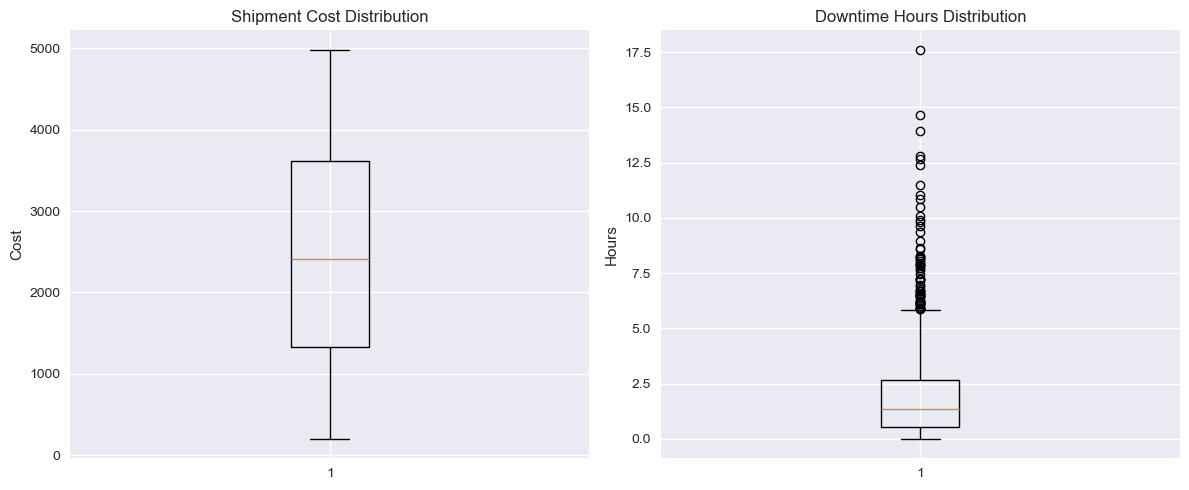

In [12]:
# IQR method on shipment cost
Q1 = logistics['shipment_cost'].quantile(0.25)
Q3 = logistics['shipment_cost'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = logistics[(logistics['shipment_cost'] < lower) | (logistics['shipment_cost'] > upper)]

print("=== Outlier Detection: Logistics Cost Spikes ===")
print(f"\nIQR Range: ${lower:.2f} — ${upper:.2f}")
print(f"Outliers detected: {len(outliers)} shipments ({len(outliers)/len(logistics)*100:.1f}% of total)")
print(f"\nTop 5 most expensive outlier shipments:")
print(outliers.nlargest(5, 'shipment_cost')[['shipment_id', 'transport_mode', 'shipment_cost', 'transit_delay_days']])

# Also check production downtime outliers
dq1 = production['downtime_hours'].quantile(0.25)
dq3 = production['downtime_hours'].quantile(0.75)
diqr = dq3 - dq1
d_upper = dq3 + 1.5 * diqr
downtime_outliers = production[production['downtime_hours'] > d_upper]

print(f"\n=== Outlier Detection: Production Downtime ===")
print(f"Extreme downtime incidents: {len(downtime_outliers)}")
print(f"Threshold: >{d_upper:.2f} hours")
print(downtime_outliers.nlargest(5, 'downtime_hours')[['production_id', 'downtime_reason', 'downtime_hours']])

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(logistics['shipment_cost'].dropna())
axes[0].set_title('Shipment Cost Distribution')
axes[0].set_ylabel('Cost')
axes[1].boxplot(production['downtime_hours'].dropna())
axes[1].set_title('Downtime Hours Distribution')
axes[1].set_ylabel('Hours')
plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150)
plt.show()

In [13]:
print("=" * 55)
print("PHASE 5 STATISTICAL ANALYSIS — SUMMARY")
print("=" * 55)
print(f"""
1. HYPOTHESIS TEST
   Delayed orders mean downtime : {delayed.mean():.2f} hrs
   On-time orders mean downtime : {on_time.mean():.2f} hrs
   P-value                      : {p_value:.4f}
   Result                       : {'Significant' if p_value < 0.05 else 'Not significant'}

2. REGRESSION (Logistics Cost)
   R² Score                     : {reg.score(X, y):.4f}
   Delay cost per day           : ${reg.coef_[1]:.2f}

3. CORRELATION (Lead Time vs Stock-outs)
   Pearson r                    : {corr:.4f}
   P-value                      : {p_val:.4f}

4. OUTLIER DETECTION
   Cost spike shipments         : {len(outliers)}
   Extreme downtime incidents   : {len(downtime_outliers)}
""")

PHASE 5 STATISTICAL ANALYSIS — SUMMARY

1. HYPOTHESIS TEST
   Delayed orders mean downtime : 1.75 hrs
   On-time orders mean downtime : 1.53 hrs
   P-value                      : 0.2026
   Result                       : Not significant

2. REGRESSION (Logistics Cost)
   R² Score                     : 0.0048
   Delay cost per day           : $-5.79

3. CORRELATION (Lead Time vs Stock-outs)
   Pearson r                    : 0.3287
   P-value                      : 0.0762

4. OUTLIER DETECTION
   Cost spike shipments         : 0
   Extreme downtime incidents   : 63

